# pyfinlib_practice — live demo

Reference/answer-key build (Oosterlee & Grzelak Ch2–6). Run cells top to
bottom with **Shift+Enter**. To change an input, edit the variable in a
cell and re-run that cell *and everything below it* — variables don't
retroactively update cells above.

## Setup
Everything below uses these five contract inputs, defined once.

In [1]:
from pyfinlib_practice.models.black_scholes import black_scholes_price
from pyfinlib_practice.pricing.greeks import delta, gamma, vega, theta, rho
import numpy as np
import pandas as pd

S0, K, r, q, sigma, T = 100.0, 105.0, 0.05, 0.0, 0.20, 1.0
print(f"spot={S0}  strike={K}  rate={r}  div={q}  vol={sigma}  maturity={T}yr")

spot=100.0  strike=105.0  rate=0.05  div=0.0  vol=0.2  maturity=1.0yr


## 1. Price one option

Black-Scholes closed form — five inputs, one formula, no simulation.

In [2]:
price = black_scholes_price(S0, K, r, sigma, T, option_type="call", q=q)
print(f"fair value of the call: {float(price):.4f}")

fair value of the call: 8.0214


## 2. Sensitivities (the Greeks)

How much that price moves if the inputs move.

In [3]:
d  = delta(S0, K, r, sigma, T, option_type="call", q=q)
g  = gamma(S0, K, r, sigma, T, q=q)
v  = vega(S0, K, r, sigma, T, q=q)
th = theta(S0, K, r, sigma, T, option_type="call", q=q)
rh = rho(S0, K, r, sigma, T, option_type="call", q=q)
print(f"delta={float(d):.4f}  gamma={float(g):.5f}  vega={float(v):.4f}"
      f"  theta={float(th):.4f}  rho={float(rh):.4f}")

delta=0.5422  gamma=0.01984  vega=39.6705  theta=-6.2771  rho=46.2015


## 3. Price a whole menu at once

Pass an array for `strike` instead of a single number — no loop needed,
this is the vectorisation convention across the whole library.

In [4]:
strikes = np.array([80., 90., 100., 110., 120.])
prices  = black_scholes_price(S0, strikes, r, sigma, T, option_type="call", q=q)
deltas  = delta(S0, strikes, r, sigma, T, option_type="call", q=q)
pd.DataFrame({"strike": strikes, "price": prices, "delta": deltas})

,strike,price,delta
0,80.0,24.588835,0.928637
1,90.0,16.699448,0.809703
2,100.0,10.450584,0.636831
3,110.0,6.040088,0.449648
4,120.0,3.247477,0.287192


## 4. Real market data: implied volatility

Run Black-Scholes *backwards* — given the price the market is actually
paying, back out the volatility the market must believe in.
`implied_volatility` is the one function in this library that only takes a
single quote at a time, so this loops over rows.

In [5]:
from pyfinlib_practice.models.local_vol import implied_volatility, risk_neutral_density, price_from_density

quotes = pd.DataFrame({
    "strike": [85., 90., 95., 100., 105., 110., 115.],
    "mid":    [21.86, 17.69, 13.85, 10.45, 8.22, 6.75, 5.76],
})
quotes["iv"] = [
    implied_volatility(row.mid, S0, row.strike, r, T, option_type="call", q=q)
    for row in quotes.itertuples()
]
quotes

,strike,mid,iv
0,85.0,21.86,0.260113
1,90.0,17.69,0.234892
2,95.0,13.85,0.215040
3,100.0,10.45,0.199984
4,105.0,8.22,0.205008
5,110.0,6.75,0.217908
6,115.0,5.76,0.233984


### The honest gotcha

Reconstruct the market's implied *probability distribution* from these
same quotes (Breeden–Litzenberger). Watch the recovered probability
mass — it should be close to 1.

In [6]:
grid_k, density = risk_neutral_density(quotes["strike"].to_numpy(), quotes["mid"].to_numpy(), r, T)
mass     = np.trapezoid(density, grid_k)
repriced = price_from_density(grid_k, density, r, T, strike=100.0, option_type="call")
print(f"7-strike chain (85-115 only) -> mass = {mass:.4f}, re-priced ATM = {repriced:.4f}"
      f" (should be close to the {float(black_scholes_price(S0,100.0,r,0.20,T,option_type='call',q=q)):.4f} quoted)")
print("Too narrow a strike range -> the function has no way to know it's missing the tails.")

wide_k     = np.linspace(40., 220., 60)
wide_smile = 0.20 + 0.15*np.log(wide_k/100.)**2 - 0.02*np.log(wide_k/100.)
wide_mid   = black_scholes_price(S0, wide_k, r, wide_smile, T, option_type="call", q=q)
wgrid_k, wdensity = risk_neutral_density(wide_k, wide_mid, r, T)
wmass     = np.trapezoid(wdensity, wgrid_k)
wrepriced = price_from_density(wgrid_k, wdensity, r, T, strike=100.0, option_type="call")
print(f"\n60-strike wide chain (40-220)  -> mass = {wmass:.4f}, re-priced ATM = {wrepriced:.4f}")

7-strike chain (85-115 only) -> mass = 0.5835, re-priced ATM = 1.2400 (should be close to the 10.4506 quoted)
Too narrow a strike range -> the function has no way to know it's missing the tails.

60-strike wide chain (40-220)  -> mass = 0.9981, re-priced ATM = 10.3142


## 5. Simulate the future 200,000 times

Instead of the formula, simulate random possible futures for the stock and
average the discounted payoff. Should land close to Step 1's answer.

In [7]:
from pyfinlib_practice.core.gbm import simulate_gbm_paths
from pyfinlib_practice.numerical.monte_carlo import monte_carlo_european_price

rng = np.random.default_rng(7)
times, paths = simulate_gbm_paths(S0, r - q, sigma, T, n_paths=200_000, n_steps=100, rng=rng)
mc = monte_carlo_european_price(paths[:, -1], K, r, T, option_type="call")
print(f"Monte Carlo: {mc.price:.4f} +/- {mc.standard_error:.4f}  (n={mc.n_paths:,})")
print(f"Closed form (Step 1): {float(price):.4f}   -- within 2 SE: {abs(mc.price-float(price)) < 2*mc.standard_error}")

Monte Carlo: 7.9670 +/- 0.0294  (n=200,000)
Closed form (Step 1): 8.0214   -- within 2 SE: True


## 6. Cross-check with a third, unrelated method

The COS method (Fourier-cosine expansion of the characteristic function,
O&G Ch6) — a completely different derivation of the same price.

In [8]:
from pyfinlib_practice.models.characteristic_functions import GBM, Merton
from pyfinlib_practice.numerical.cos import cos_european_price
from pyfinlib_practice.models.jump_diffusion import merton_jump_price

gbm_model  = GBM(r=r, q=q, sigma=sigma)
cos_prices = cos_european_price(gbm_model.cf, gbm_model.cumulants, S0, strikes, r, T, n=128, option_type="call")
print("max |COS - closed form| across all 5 strikes:", np.max(np.abs(cos_prices - prices)))

merton_model  = Merton(r=r, q=q, sigma=0.15, lam=0.5, mu_j=-0.10, sigma_j=0.15)
cos_merton    = cos_european_price(merton_model.cf, merton_model.cumulants, S0, strikes, r, T, n=256, option_type="call")
series_merton = merton_jump_price(S0, strikes, r, sigma=0.15, t=T, lam=0.5, mu_j=-0.10, sigma_j=0.15, q=q, option_type="call")
print("max |COS - analytic series| (Merton, unrelated formula):", np.max(np.abs(cos_merton - series_merton)))

max |COS - closed form| across all 5 strikes: 5.5067062021407764e-14
max |COS - analytic series| (Merton, unrelated formula): 4.973799150320701e-13


## 7. Where the standard approach breaks

Sell the option, then run a textbook weekly delta-hedge. Compare a market
that only wobbles smoothly (GBM) against one that can also jump suddenly
(Merton) — same hedge, same rebalancing.

In [9]:
from pyfinlib_practice.pricing.hedging import delta_hedge_pnl

pnl_gbm = delta_hedge_pnl(S0, K, r, sigma, T, n_steps=52, n_paths=20_000,
                           option_type="call", rng=np.random.default_rng(1))
pnl_merton = delta_hedge_pnl(S0, K, r, sigma, T, n_steps=52, n_paths=20_000,
                              option_type="call", lam=0.5, mu_j=-0.10, sigma_j=0.15,
                              rng=np.random.default_rng(1))
print(f"GBM    hedge P&L:  mean={pnl_gbm.mean():+.4f}   std={pnl_gbm.std():.4f}")
print(f"Merton hedge P&L:  mean={pnl_merton.mean():+.4f}   std={pnl_merton.std():.4f}   <- jump risk can't be hedged away")

GBM    hedge P&L:  mean=+0.0108   std=1.0092
Merton hedge P&L:  mean=-1.2212   std=3.1972   <- jump risk can't be hedged away


## Bonus: a picture instead of a table

The implied vol smile and the priced curve, plotted from the same
functions used above.

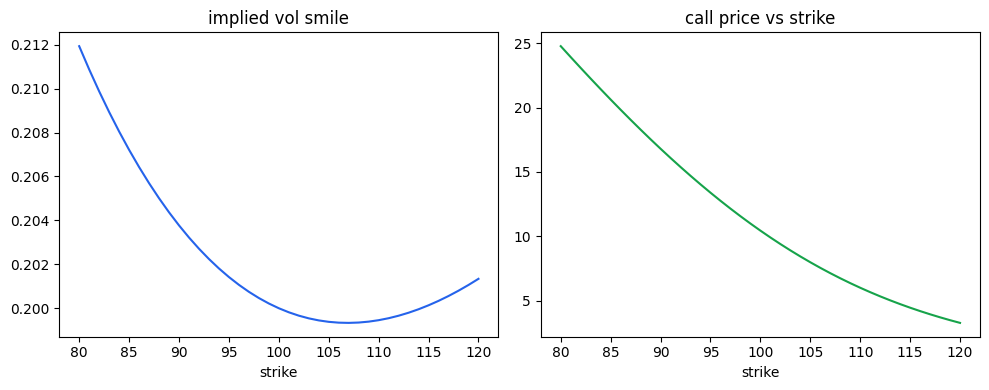

In [10]:
import matplotlib.pyplot as plt

fine_strikes = np.linspace(80, 120, 41)
fine_vols    = 0.20 + 0.15*np.log(fine_strikes/100.)**2 - 0.02*np.log(fine_strikes/100.)
fine_prices  = black_scholes_price(S0, fine_strikes, r, fine_vols, T, option_type="call", q=q)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(fine_strikes, fine_vols, color="#2563eb"); ax1.set_title("implied vol smile"); ax1.set_xlabel("strike")
ax2.plot(fine_strikes, fine_prices, color="#16a34a"); ax2.set_title("call price vs strike"); ax2.set_xlabel("strike")
fig.tight_layout()
plt.show()